<a href="https://colab.research.google.com/github/aljaziya/project1/blob/main/xray_nonxray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [2]:
# Define paths to the dataset
train_dir = '/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/train'  # Update with your actual path
test_dir = '/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/test'    # Update with your actual path

In [4]:
import os
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/train/xray')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/train/non_xray')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/test/xray')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/test/non_xray')))

565
621
565
203


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (cats vs. dogs)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 949 images belonging to 2 classes.
Found 236 images belonging to 2 classes.


In [6]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [7]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten()) #converting 2D to 1 D

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [9]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 410s 13s/step - accuracy: 0.8988 - loss: 0.3260 - val_accuracy: 0.9831 - val_loss: 0.0698
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step - accuracy: 0.9968 - loss: 0.0092 - val_accuracy: 0.9619 - val_loss: 0.1530
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.9895 - loss: 0.0325 - val_accuracy: 0.9831 - val_loss: 0.0542
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9831 - val_loss: 0.0427
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9831 - val_loss: 0.1077
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 1.0000 - loss: 4.5779e-04 - val_accuracy: 0.9788 - val_loss: 0.1193
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 1.0000 - loss: 4.4595e-05 - val_accuracy: 0.9788 - val_loss: 0.1621
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 1.0000 - loss: 1.9061e-05 - val_

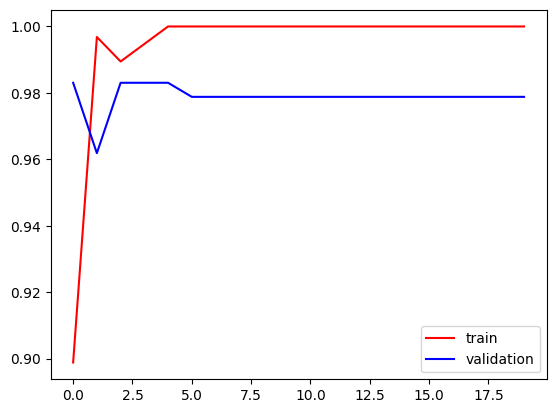

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

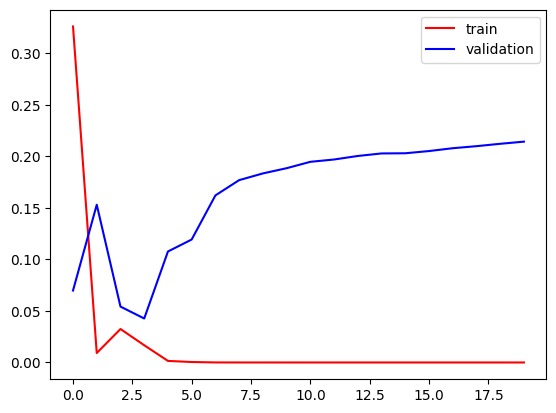

In [11]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 1115 images belonging to 2 classes.


In [13]:
#predict the test data
predictions = model.predict(test_data)


35/35 ━━━━━━━━━━━━━━━━━━━━ 208s 6s/step


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[258 293]
 [288 276]]
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47       551
           1       0.49      0.49      0.49       564

    accuracy                           0.48      1115
   macro avg       0.48      0.48      0.48      1115
weighted avg       0.48      0.48      0.48      1115



In [15]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [17]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 421ms/step - accuracy: 0.9515 - loss: 1.0397 - val_accuracy: 0.7627 - val_loss: 3.6375
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.9958 - loss: 0.1947 - val_accuracy: 0.4746 - val_loss: 22.8110
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - accuracy: 0.9789 - loss: 0.5648 - val_accuracy: 0.6229 - val_loss: 16.6870
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 249ms/step - accuracy: 0.9852 - loss: 0.6461 - val_accuracy: 0.8771 - val_loss: 8.2487
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.9926 - loss: 0.4871 - val_accuracy: 0.6864 - val_loss: 14.4742
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - accuracy: 0.9916 - loss: 0.4430 - val_accuracy: 0.8263 - val_loss: 13.0421
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.9958 - loss: 0.2296 - val_accuracy: 0.7500 - val_loss: 12.0011
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.9937 - loss: 0.1230 - val_accur

In [18]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 1115 images belonging to 2 classes.


In [19]:
predictions = model.predict(test_data)

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step


In [20]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[268 283]
 [274 290]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.49      0.49      0.49       551
           1       0.51      0.51      0.51       564

    accuracy                           0.50      1115
   macro avg       0.50      0.50      0.50      1115
weighted avg       0.50      0.50      0.50      1115



In [22]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

In [23]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [24]:
history = resnet_model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 755ms/step - accuracy: 0.5869 - loss: 1.7183 - val_accuracy: 0.5297 - val_loss: 1.2264
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.7260 - loss: 0.5294 - val_accuracy: 0.6102 - val_loss: 0.6663
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step - accuracy: 0.8651 - loss: 0.3354 - val_accuracy: 0.7754 - val_loss: 0.4425
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms/step - accuracy: 0.9062 - loss: 0.2731 - val_accuracy: 0.8517 - val_loss: 0.3467
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - accuracy: 0.9283 - loss: 0.2257 - val_accuracy: 0.7839 - val_loss: 0.4295
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 271ms/step - accuracy: 0.9368 - loss: 0.1986 - val_accuracy: 0.8686 - val_loss: 0.2957
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.9389 - loss: 0.1855 - val_accuracy: 0.8814 - val_loss: 0.3041
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 267ms/step - accuracy: 0.9399 - loss: 0.1642 - val_accuracy: 0

In [25]:
predictions = resnet_model.predict(test_data)

35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 396ms/step


In [26]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[263 288]
 [251 313]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.51      0.48      0.49       551
           1       0.52      0.55      0.54       564

    accuracy                           0.52      1115
   macro avg       0.52      0.52      0.52      1115
weighted avg       0.52      0.52      0.52      1115

